# Laboratorio 4 — Ejercicio 2

## Modelo de Producción con Períodos Múltiples (ACME Manufacturing Company)

ACME Manufacturing Company firmó un contrato para entregar 180, 250, 190, 140, 220 y 250 ventanas para casa durante los siguientes seis meses. El costo de producción (mano de obra, material y servicios) por ventana varía por período y se estima que será de \$50, \$45, \$55, \$52, \$48 y \$50 durante los próximos seis meses.

Para aprovechar las fluctuaciones del costo de fabricación, ACME puede producir más ventanas de las necesarias en un mes dado y conservar las unidades adicionales para entregarlas en meses posteriores. Esto supondrá un costo de almacenamiento del inventario a fin de mes, a razón de \$8 por ventana por mes en los meses 1, 5 y 6; en los meses 2, 3 y 4 los costos por almacenaje son de \$10 por ventana debido a la temporada de alta demanda. La empresa tiene una capacidad máxima de producción de 225 ventanas cada mes.

**a)** Formular el problema de programación lineal.

**b)** Resolver el problema usando la librería JuMP o Pulp, en variables continuas, y determinar la producción óptima. Hacer un diagrama o esquema de la producción óptima indicando las producciones en cada mes, así como los inventarios. Comparar contra la solución (no óptima) que produce exactamente la demanda de cada mes. Elaborar una tabla mes a mes, indicando los costos de producción, los costos de inventario, el costo total y el ahorro generado al compararlo con la producción no óptima anterior.

**c)** ¿Se obtiene la misma solución óptima al introducir restricciones enteras?

## Resumen del ejercicio

Este es un problema clásico de **planeación de la producción con inventarios en períodos múltiples** (*lot sizing*). La empresa debe decidir cuántas ventanas fabricar en cada uno de los seis meses del contrato sabiendo que el costo unitario de producción cambia mes a mes. Producir por adelantado en un mes barato permite ahorrar en el costo de fabricación, pero obliga a pagar almacenamiento por cada ventana que se conserva hasta el mes en que se entrega; producir justo lo que se necesita evita el almacenaje pero paga siempre el costo del mes corriente, y además puede ser inviable cuando la demanda de un mes supera la capacidad de la planta.

El modelo se construye sobre dos familias de variables: la **producción** $x_t$ de cada mes y el **inventario** $I_t$ que queda al final de cada mes. Ambas se enlazan mediante la *ecuación de balance de inventario*

$$I_{t-1} + x_t - I_t = d_t,$$

que expresa que lo que había al inicio del mes más lo producido, menos lo que sobra al final, es exactamente lo que se entregó. Esta ecuación es la que convierte seis decisiones independientes en una sola cadena acoplada a lo largo del horizonte de planeación, y es lo que hace que el problema deba resolverse como un único programa lineal y no mes por mes.

La función objetivo suma el costo de producción $c_t x_t$ y el costo de almacenamiento $h_t I_t$ de todos los meses, y se minimiza sujeta al balance de inventario, a la capacidad de 225 ventanas por mes y a la no negatividad de todas las variables.

## Objetivo y referencias

Se formulará y resolverá el modelo de producción e inventario de ACME usando la librería **Pulp**, que construye el programa lineal de forma declarativa y lo resuelve con el solver **CBC** (*COIN-OR Branch and Cut*). El mismo modelo se resolverá dos veces: primero en variables continuas (inciso b) y luego declarando las variables como enteras (inciso c), para comparar ambas soluciones.

El desarrollo se apoya en `pulp` para el modelado y la optimización, `pandas` para construir las tablas mes a mes de costos y ahorros, y `matplotlib` para el esquema de la producción óptima —una reproducción de la Figura 1 del enunciado con los valores obtenidos— y para las gráficas comparativas. La estructura del notebook replica la de los laboratorios anteriores del curso: planteamiento, formulación, implementación, validación y conclusión.

## 1. Datos del problema

Se cargan los datos del enunciado: la demanda contratada $d_t$, el costo unitario de producción $c_t$, el costo unitario de almacenamiento a fin de mes $h_t$ y la capacidad mensual de producción.

In [1]:
import numpy as np
import pandas as pd
import pulp
import matplotlib.pyplot as plt

MESES = 6
meses = np.arange(1, MESES + 1)

# Demanda contratada de ventanas en cada mes.
d = np.array([180, 250, 190, 140, 220, 250])

# Costo unitario de producción (mano de obra, material y servicios) por mes.
c = np.array([50, 45, 55, 52, 48, 50])

# Costo unitario de almacenamiento del inventario a fin de mes:
# $8 en los meses 1, 5 y 6; $10 en los meses 2, 3 y 4 (temporada alta).
h = np.array([8, 10, 10, 10, 8, 8])

# Capacidad máxima de producción por mes.
CAPACIDAD = 225

datos = pd.DataFrame({
    "Mes": meses,
    "Demanda d_t": d,
    "Costo producción c_t": c,
    "Costo inventario h_t": h,
    "Capacidad": CAPACIDAD,
})

print(f"Demanda total del contrato: {d.sum()} ventanas")
print(f"Capacidad total del horizonte: {CAPACIDAD * MESES} ventanas")
print(f"Holgura de capacidad: {CAPACIDAD * MESES - d.sum()} ventanas")
datos

Demanda total del contrato: 1230 ventanas
Capacidad total del horizonte: 1350 ventanas
Holgura de capacidad: 120 ventanas


,Mes,Demanda d_t,Costo producción c_t,Costo inventario h_t,Capacidad
0,1,180,50,8,225
1,2,250,45,10,225
2,3,190,55,10,225
3,4,140,52,10,225
4,5,220,48,8,225
5,6,250,50,8,225


### Explicación de esta parte:

`d`, `c` y `h` recogen respectivamente la demanda, el costo de producción y el costo de almacenamiento de cada uno de los seis meses tal como los da el enunciado; nótese que `h` no es constante, pues vale 8 en los meses 1, 5 y 6 y sube a 10 en los meses 2, 3 y 4 por la temporada de alta demanda. La comparación entre la demanda total del contrato (1230 ventanas) y la capacidad total del horizonte (6 × 225 = 1350 ventanas) confirma que el problema **es factible**: existe capacidad suficiente para cumplir todo el contrato. Sin embargo, esa holgura de 120 ventanas es agregada, y más adelante se verá que la capacidad sí se vuelve restrictiva en meses individuales.

## 2. Formulación del programa lineal (inciso a)

**Variables de decisión.** Para cada mes $t = 1,\ldots,6$:

$$x_t = \text{número de ventanas producidas en el mes } t, \qquad I_t = \text{inventario de ventanas al final del mes } t.$$

**Función objetivo.** Minimizar el costo total, que es la suma del costo de producción y el costo de almacenamiento a lo largo del horizonte:

$$\min \; z = \sum_{t=1}^{6} c_t\,x_t \;+\; \sum_{t=1}^{6} h_t\,I_t,$$

con $c = (50, 45, 55, 52, 48, 50)$ y $h = (8, 10, 10, 10, 8, 8)$.

**Restricciones de balance de inventario.** Lo disponible al inicio del mes más lo producido debe cubrir la demanda del mes y dejar el inventario final:

$$I_{t-1} + x_t - I_t = d_t, \qquad t = 1,\ldots,6,$$

con la condición inicial $I_0 = 0$ (no hay inventario antes de iniciar el contrato).

**Restricciones de capacidad.** La planta no puede fabricar más de 225 ventanas por mes:

$$x_t \le 225, \qquad t = 1,\ldots,6.$$

**Condición de fin de horizonte.** No tiene sentido dejar inventario sobrante al terminar el contrato, pues generaría costo de almacenaje sin demanda que atender:

$$I_6 = 0.$$

**No negatividad.**

$$x_t \ge 0, \qquad I_t \ge 0, \qquad t = 1,\ldots,6.$$

El modelo completo, escrito de forma explícita, es:

$$
\begin{aligned}
\min \quad & 50x_1 + 45x_2 + 55x_3 + 52x_4 + 48x_5 + 50x_6 + 8I_1 + 10I_2 + 10I_3 + 10I_4 + 8I_5 + 8I_6 \\
\text{s.a.} \quad & x_1 - I_1 = 180 \\
& I_1 + x_2 - I_2 = 250 \\
& I_2 + x_3 - I_3 = 190 \\
& I_3 + x_4 - I_4 = 140 \\
& I_4 + x_5 - I_5 = 220 \\
& I_5 + x_6 - I_6 = 250 \\
& x_t \le 225, \quad t = 1,\ldots,6 \\
& I_6 = 0 \\
& x_t,\, I_t \ge 0, \quad t = 1,\ldots,6.
\end{aligned}
$$

Se trata de un programa lineal con 12 variables y 13 restricciones (sin contar las cotas de no negatividad).

## 3. Implementación y solución en variables continuas (inciso b)

Se traduce la formulación anterior a Pulp. La capacidad se declara directamente como cota superior (`upBound`) de las variables de producción, y el balance de inventario se agrega como una restricción de igualdad por cada mes.

In [2]:
# Construye y resuelve el modelo de ACME. El parámetro `categoria` permite
# reutilizar la misma formulación en variables continuas y en variables enteras.
def resolver_acme(categoria="Continuous"):
    modelo = pulp.LpProblem("ACME_produccion_inventario", pulp.LpMinimize)

    x = [pulp.LpVariable(f"x{t+1}", lowBound=0, upBound=CAPACIDAD, cat=categoria)
         for t in range(MESES)]
    I = [pulp.LpVariable(f"I{t+1}", lowBound=0, cat=categoria)
         for t in range(MESES)]

    # Función objetivo: costo de producción + costo de almacenamiento.
    modelo += (pulp.lpSum(c[t] * x[t] for t in range(MESES))
               + pulp.lpSum(h[t] * I[t] for t in range(MESES))), "Costo_total"

    # Balance de inventario: I_{t-1} + x_t - I_t = d_t, con I_0 = 0.
    for t in range(MESES):
        inventario_inicial = 0 if t == 0 else I[t - 1]
        modelo += (inventario_inicial + x[t] - I[t] == d[t]), f"Balance_mes_{t+1}"

    # No queda inventario al terminar el contrato.
    modelo += (I[MESES - 1] == 0), "Fin_de_horizonte"

    modelo.solve(pulp.PULP_CBC_CMD(msg=0))

    x_sol = np.array([v.value() for v in x])
    I_sol = np.array([v.value() for v in I])
    return modelo, x_sol, I_sol

### Explicación de esta parte:

`resolver_acme` encapsula toda la formulación del inciso (a). Las variables de producción se crean con `lowBound=0` y `upBound=CAPACIDAD`, de modo que la restricción $0 \le x_t \le 225$ queda incorporada en la propia declaración de la variable en lugar de escribirse como una fila adicional del modelo. El ciclo que agrega `Balance_mes_t` implementa la ecuación de balance $I_{t-1} + x_t - I_t = d_t$; para el primer mes el inventario inicial se fija en `0` porque no hay existencias antes de comenzar el contrato. El argumento `categoria` es lo único que cambiará en el inciso (c): pasando `"Integer"` se obtiene exactamente el mismo modelo pero con variables enteras, lo que garantiza que la comparación entre ambas versiones sea limpia.

In [3]:
modelo_lp, x_lp, I_lp = resolver_acme("Continuous")

costo_produccion_lp = float((c * x_lp).sum())
costo_inventario_lp = float((h * I_lp).sum())
costo_total_lp = pulp.value(modelo_lp.objective)

print(f"Estado del solver: {pulp.LpStatus[modelo_lp.status]}")
print(f"\nProducción óptima x_t : {x_lp}")
print(f"Inventario final  I_t : {I_lp}")
print(f"\nCosto de producción   : ${costo_produccion_lp:,.2f}")
print(f"Costo de inventario   : ${costo_inventario_lp:,.2f}")
print(f"Costo total óptimo z  : ${costo_total_lp:,.2f}")

Estado del solver: Optimal

Producción óptima x_t : [205. 225. 190. 160. 225. 225.]
Inventario final  I_t : [25.  0.  0. 20. 25.  0.]

Costo de producción   : $61,195.00
Costo de inventario   : $600.00
Costo total óptimo z  : $61,795.00


### Explicación de esta parte:

El solver CBC devuelve el estado `Optimal`, lo que confirma que el modelo es factible y que la solución encontrada es óptima global (al ser un programa lineal, todo óptimo local lo es también global). La producción óptima resulta ser $x = (205, 225, 190, 160, 225, 225)$ con inventarios finales $I = (25, 0, 0, 20, 25, 0)$, y el costo total mínimo es de **\$61,795**, del cual \$61,195 corresponden a fabricación y solo \$600 a almacenamiento. Obsérvese que la producción se anticipa exactamente en tres puntos: 25 ventanas en el mes 1, 20 en el mes 4 y 25 en el mes 5, que son las que se guardan en inventario para entregarse al mes siguiente.

## 4. Esquema de la producción óptima

Se reproduce el esquema de la Figura 1 del enunciado —la línea de flujo de producción e inventario— sustituyendo los símbolos por los valores óptimos obtenidos: las flechas que entran por arriba son las producciones $x_t$, las flechas que salen por abajo son las demandas $d_t$ entregadas, y los valores sobre la línea horizontal son los inventarios $I_t$ que se trasladan de un mes al siguiente.

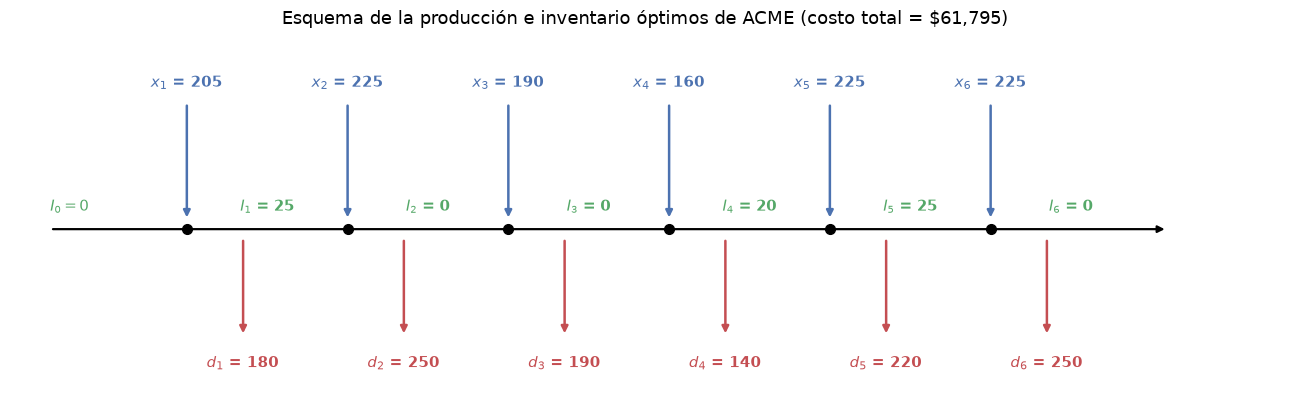

In [4]:
fig, ax = plt.subplots(figsize=(13, 4.2))

# Línea horizontal de flujo de inventario a lo largo de los seis meses.
ax.annotate("", xy=(6.6, 0), xytext=(-0.35, 0),
            arrowprops=dict(arrowstyle="-|>", color="black", lw=1.6))

for t in range(MESES):
    pos = t + 0.5

    # Flecha de producción entrando al nodo del mes.
    ax.annotate("", xy=(pos, 0.06), xytext=(pos, 0.85),
                arrowprops=dict(arrowstyle="-|>", color="#4C72B0", lw=1.8))
    ax.text(pos, 0.93, f"$x_{{{t+1}}}$ = {x_lp[t]:.0f}", ha="center", va="bottom",
            fontsize=11, color="#4C72B0", fontweight="bold")

    # Flecha de demanda saliendo del nodo del mes.
    ax.annotate("", xy=(pos + 0.35, -0.72), xytext=(pos + 0.35, -0.06),
                arrowprops=dict(arrowstyle="-|>", color="#C44E52", lw=1.8))
    ax.text(pos + 0.35, -0.85, f"$d_{{{t+1}}}$ = {d[t]:.0f}", ha="center", va="top",
            fontsize=11, color="#C44E52", fontweight="bold")

    # Inventario que se traslada al mes siguiente, rotulado sobre la línea.
    ax.text(pos + 0.5, 0.10, f"$I_{{{t+1}}}$ = {I_lp[t]:.0f}", ha="center", va="bottom",
            fontsize=10.5, color="#55A868", fontweight="bold")

    ax.plot([pos], [0], marker="o", color="black", markersize=7, zorder=3)

ax.text(-0.35, 0.10, "$I_0 = 0$", ha="left", va="bottom", fontsize=10.5, color="#55A868")
ax.set_xlim(-0.6, 7.3)
ax.set_ylim(-1.15, 1.25)
ax.axis("off")
ax.set_title("Esquema de la producción e inventario óptimos de ACME "
             f"(costo total = \\${costo_total_lp:,.0f})", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

### Explicación de esta parte:

El esquema replica la representación de la Figura 1 del enunciado con los valores de la solución óptima. Cada nodo negro sobre la línea horizontal representa el final de un mes: por arriba entra la producción $x_t$ (en azul), por abajo sale la demanda entregada $d_t$ (en rojo) y sobre la línea viaja el inventario $I_t$ (en verde) que pasa al mes siguiente. Se aprecia con claridad la estructura de la solución: el flujo de inventario es cero en la mayoría de los tramos, y solo se cargan existencias en tres puntos —25 unidades del mes 1 al 2, 20 del mes 4 al 5 y 25 del mes 5 al 6— que son precisamente los meses previos a los períodos donde la demanda excede la capacidad de la planta.

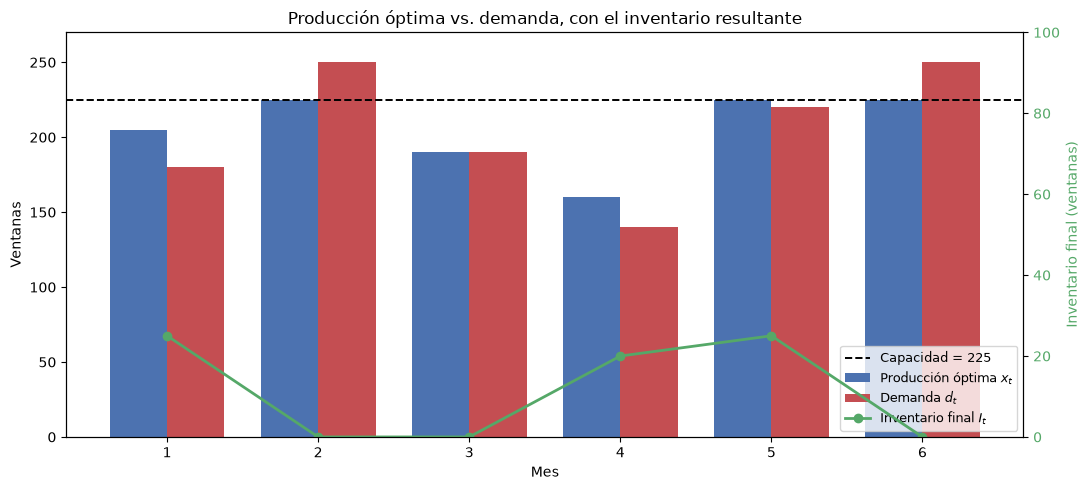

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ancho = 0.38

ax.bar(meses - ancho/2, x_lp, width=ancho, label="Producción óptima $x_t$", color="#4C72B0")
ax.bar(meses + ancho/2, d, width=ancho, label="Demanda $d_t$", color="#C44E52")
ax.axhline(CAPACIDAD, color="black", linestyle="--", lw=1.4,
           label=f"Capacidad = {CAPACIDAD}")

ax2 = ax.twinx()
ax2.plot(meses, I_lp, marker="o", color="#55A868", lw=2,
         label="Inventario final $I_t$")
ax2.set_ylabel("Inventario final (ventanas)", color="#55A868")
ax2.tick_params(axis="y", labelcolor="#55A868")
ax2.set_ylim(0, max(I_lp.max() * 4, 1))

ax.set_xlabel("Mes")
ax.set_ylabel("Ventanas")
ax.set_title("Producción óptima vs. demanda, con el inventario resultante")
ax.set_xticks(meses)
ax.set_ylim(0, 270)
lineas1, etiquetas1 = ax.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

### Explicación de esta parte:

La gráfica de barras contrasta, mes a mes, lo que se produce contra lo que se debe entregar, y la línea verde muestra el inventario que resulta de esa diferencia. La línea punteada de capacidad deja ver el hecho central del problema: en los meses 2 y 6 la demanda (250 ventanas) **está por encima de la capacidad** de 225, de modo que es imposible fabricar en esos meses todo lo que se debe entregar. Las barras azules que sobresalen de las rojas en los meses 1, 4 y 5 son justamente la producción anticipada que compensa esa limitación, y coinciden con los picos de la línea de inventario.

## 5. Comparación con la política que produce exactamente la demanda

El enunciado pide comparar la solución óptima contra la política no óptima que produce en cada mes exactamente la demanda de ese mes, es decir $x_t = d_t$ e $I_t = 0$ para todo $t$. Antes de comparar costos es indispensable verificar si esa política es **factible** bajo la capacidad de 225 ventanas mensuales.

In [6]:
x_jit = d.astype(float)          # Política "producir exactamente la demanda": x_t = d_t
I_jit = np.zeros(MESES)          # Sin producción anticipada no se acumula inventario

violaciones = meses[x_jit > CAPACIDAD]
costo_produccion_jit = float((c * x_jit).sum())
costo_inventario_jit = float((h * I_jit).sum())
costo_total_jit = costo_produccion_jit + costo_inventario_jit

print("Política que produce exactamente la demanda (x_t = d_t):")
print(f"  Producción x_t : {x_jit}")
print(f"  Inventario I_t : {I_jit}")
print(f"  Costo de producción : ${costo_produccion_jit:,.2f}")
print(f"  Costo de inventario : ${costo_inventario_jit:,.2f}")
print(f"  Costo total         : ${costo_total_jit:,.2f}")

if len(violaciones) > 0:
    print(f"\n*** Esta política es INFACTIBLE ***")
    for t in violaciones:
        print(f"  Mes {t}: requiere producir {d[t-1]} ventanas, "
              f"pero la capacidad es de {CAPACIDAD} "
              f"(exceso de {d[t-1] - CAPACIDAD} ventanas).")
else:
    print("\nLa política respeta la capacidad en todos los meses.")

Política que produce exactamente la demanda (x_t = d_t):
  Producción x_t : [180. 250. 190. 140. 220. 250.]
  Inventario I_t : [0. 0. 0. 0. 0. 0.]
  Costo de producción : $61,040.00
  Costo de inventario : $0.00
  Costo total         : $61,040.00

*** Esta política es INFACTIBLE ***
  Mes 2: requiere producir 250 ventanas, pero la capacidad es de 225 (exceso de 25 ventanas).
  Mes 6: requiere producir 250 ventanas, pero la capacidad es de 225 (exceso de 25 ventanas).


### Explicación de esta parte:

La política de producir exactamente la demanda tendría un costo de \$61,040, íntegramente de fabricación y sin ningún gasto de almacenamiento. Sin embargo, **no es una solución admisible del problema**: en los meses 2 y 6 exige fabricar 250 ventanas cuando la planta solo puede producir 225, un exceso de 25 unidades en cada uno de esos meses. Su costo no es entonces una alternativa real de operación, sino una **cota inferior inalcanzable**: es lo que costaría el contrato si la capacidad fuera ilimitada y jamás hiciera falta almacenar. Comparar el óptimo contra ella no mide un ahorro, sino el sobrecosto que impone la restricción de capacidad.

Para tener una comparación entre dos planes que la empresa realmente podría ejecutar, en la siguiente celda se construye una segunda política de referencia: la política de **anticipación mínima**, que produce justo a tiempo siempre que puede y adelanta producción únicamente cuando la capacidad la obliga a hacerlo.

In [7]:
# Política de anticipación mínima: se produce justo a tiempo y solo se adelanta
# el excedente que la capacidad impide fabricar en su propio mes. Se recorre el
# horizonte de atrás hacia adelante empujando hacia el mes previo lo que no cabe.
x_ref = d.astype(float).copy()
for t in range(MESES - 1, 0, -1):
    exceso = x_ref[t] - CAPACIDAD
    if exceso > 0:
        x_ref[t] -= exceso
        x_ref[t - 1] += exceso

# Inventarios que genera esa política, por el balance I_t = I_{t-1} + x_t - d_t.
I_ref = np.zeros(MESES)
inventario = 0.0
for t in range(MESES):
    inventario = inventario + x_ref[t] - d[t]
    I_ref[t] = inventario

costo_produccion_ref = float((c * x_ref).sum())
costo_inventario_ref = float((h * I_ref).sum())
costo_total_ref = costo_produccion_ref + costo_inventario_ref

print("Política factible de anticipación mínima:")
print(f"  Producción x_t : {x_ref}")
print(f"  Inventario I_t : {I_ref}")
print(f"  ¿Respeta la capacidad? {bool((x_ref <= CAPACIDAD).all())}")
print(f"  Costo de producción : ${costo_produccion_ref:,.2f}")
print(f"  Costo de inventario : ${costo_inventario_ref:,.2f}")
print(f"  Costo total         : ${costo_total_ref:,.2f}")
print(f"\nCosto total óptimo (Pulp) : ${costo_total_lp:,.2f}")
print(f"Diferencia respecto al óptimo: ${costo_total_ref - costo_total_lp:,.2f}")
print(f"¿Coincide con la solución óptima? "
      f"{bool(np.allclose(x_ref, x_lp) and np.allclose(I_ref, I_lp))}")

Política factible de anticipación mínima:
  Producción x_t : [205. 225. 190. 160. 225. 225.]
  Inventario I_t : [25.  0.  0. 20. 25.  0.]
  ¿Respeta la capacidad? True
  Costo de producción : $61,195.00
  Costo de inventario : $600.00
  Costo total         : $61,795.00

Costo total óptimo (Pulp) : $61,795.00
Diferencia respecto al óptimo: $0.00
¿Coincide con la solución óptima? True


### Explicación de esta parte:

La política de anticipación mínima se construye recorriendo el horizonte de atrás hacia adelante: cuando un mes exige producir más de 225 ventanas, el excedente se empuja al mes anterior, y el proceso se repite hacia atrás por si ese traslado vuelve a rebasar la capacidad. Así, las 25 ventanas que no caben en el mes 2 se fabrican en el mes 1, y las 25 que no caben en el mes 6 se fabrican en el mes 5, lo que a su vez obliga a mover 20 ventanas del mes 5 al mes 4.

El resultado es notable: esta política **coincide exactamente con la solución óptima** encontrada por Pulp, $x = (205, 225, 190, 160, 225, 225)$. Es decir, en este problema toda la producción anticipada que conviene hacer es únicamente la que la capacidad obliga a hacer, y ninguna unidad adicional se adelanta por motivos de costo. La razón es que los diferenciales de precio no alcanzan a pagar el almacenaje: adelantar una ventana del mes 3 (\$55) al mes 2 (\$45) ahorraría \$10 de fabricación pero costaría \$10 de almacenamiento, quedando en tablas, y cualquier otra anticipación por conveniencia resulta directamente más cara —por ejemplo, producir en el mes 1 (\$50) para entregar en el mes 3 (\$55) implicaría pagar \$8 + \$10 = \$18 de almacenaje para ahorrar solo \$5 de fabricación.

## 6. Tabla mes a mes de costos y ahorro

Se construye la tabla solicitada, con el costo de producción, el costo de inventario y el costo total de cada mes, tanto para la producción óptima como para la política no óptima que produce exactamente la demanda.

In [8]:
tabla = pd.DataFrame({
    "Mes": meses,
    "Demanda d_t": d,
    "Producción óptima x_t": x_lp,
    "Inventario óptimo I_t": I_lp,
    "Costo producción óptimo": c * x_lp,
    "Costo inventario óptimo": h * I_lp,
    "Costo total óptimo": c * x_lp + h * I_lp,
    "Producción x_t = d_t": x_jit,
    "Costo producción x_t = d_t": c * x_jit,
    "Costo inventario x_t = d_t": h * I_jit,
    "Costo total x_t = d_t": c * x_jit + h * I_jit,
})
tabla["Ahorro del óptimo"] = tabla["Costo total x_t = d_t"] - tabla["Costo total óptimo"]

totales = tabla.drop(columns="Mes").sum()
totales["Demanda d_t"] = d.sum()
tabla_con_total = pd.concat(
    [tabla, pd.DataFrame([{"Mes": "TOTAL", **totales.to_dict()}])],
    ignore_index=True,
)

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
tabla_con_total

,Mes,Demanda d_t,Producción óptima x_t,Inventario óptimo I_t,Costo producción óptimo,Costo inventario óptimo,Costo total óptimo,Producción x_t = d_t,Costo producción x_t = d_t,Costo inventario x_t = d_t,Costo total x_t = d_t,Ahorro del óptimo
0,1,180.00,205.00,25.00,"10,250.00",200.00,"10,450.00",180.00,"9,000.00",0.00,"9,000.00","-1,450.00"
1,2,250.00,225.00,0.00,"10,125.00",0.00,"10,125.00",250.00,"11,250.00",0.00,"11,250.00","1,125.00"
2,3,190.00,190.00,0.00,"10,450.00",0.00,"10,450.00",190.00,"10,450.00",0.00,"10,450.00",0.00
3,4,140.00,160.00,20.00,"8,320.00",200.00,"8,520.00",140.00,"7,280.00",0.00,"7,280.00","-1,240.00"
4,5,220.00,225.00,25.00,"10,800.00",200.00,"11,000.00",220.00,"10,560.00",0.00,"10,560.00",-440.00
5,6,250.00,225.00,0.00,"11,250.00",0.00,"11,250.00",250.00,"12,500.00",0.00,"12,500.00","1,250.00"
6,TOTAL,"1,230.00","1,230.00",70.00,"61,195.00",600.00,"61,795.00","1,230.00","61,040.00",0.00,"61,040.00",-755.00


### Explicación de esta parte:

La tabla desglosa mes a mes ambos planes. En la producción óptima, el costo de fabricación asciende a \$61,195 y el de almacenamiento a solo \$600 (25 ventanas × \$8 en el mes 1, 20 × \$10 en el mes 4 y 25 × \$8 en el mes 5), para un costo total de **\$61,795**. La política que produce exactamente la demanda acumularía \$61,040, todo de fabricación. La columna de ahorro es por tanto **negativa**, de −\$755 en total: el plan óptimo cuesta \$755 más que la política de referencia. Esto no contradice la optimalidad del resultado, porque —como se verificó en la sección anterior— esa política es infactible: viola la capacidad en los meses 2 y 6 y no puede ejecutarse. Los \$755 son exactamente el **sobrecosto que impone la restricción de capacidad**: lo que la empresa debe pagar de más, entre fabricación adelantada y almacenaje, por no poder producir 250 ventanas en un solo mes.

Frente a la única política de referencia que sí es ejecutable —la de anticipación mínima de la sección 5— el ahorro es de \$0, porque esa política y el óptimo son el mismo plan de producción.

In [9]:
resumen = pd.DataFrame({
    "Plan": ["Óptimo (Pulp)",
             "Anticipación mínima (factible)",
             "Producir exactamente la demanda"],
    "Costo de producción": [costo_produccion_lp, costo_produccion_ref, costo_produccion_jit],
    "Costo de inventario": [costo_inventario_lp, costo_inventario_ref, costo_inventario_jit],
    "Costo total": [costo_total_lp, costo_total_ref, costo_total_jit],
    "¿Factible?": ["Sí", "Sí", "No (excede capacidad en los meses 2 y 6)"],
})
resumen["Diferencia vs. óptimo"] = resumen["Costo total"] - costo_total_lp
resumen

,Plan,Costo de producción,Costo de inventario,Costo total,¿Factible?,Diferencia vs. óptimo
0,Óptimo (Pulp),"61,195.00",600.00,"61,795.00",Sí,0.00
1,Anticipación mínima (factible),"61,195.00",600.00,"61,795.00",Sí,0.00
2,Producir exactamente la demanda,"61,040.00",0.00,"61,040.00",No (excede capacidad en los meses 2 y 6),-755.00


### Explicación de esta parte:

El resumen coloca los tres planes lado a lado. Entre los planes **factibles**, el óptimo de Pulp y la política de anticipación mínima tienen el mismo costo de \$61,795, y no existe ningún otro plan ejecutable más barato —eso es precisamente lo que garantiza la optimalidad reportada por el solver. El tercer plan aparece con un costo menor, \$61,040, únicamente porque ignora la capacidad de la planta; su verdadera utilidad es servir como cota inferior teórica y cuantificar en \$755 el costo de la limitación productiva.

## 7. Modelo con variables enteras (inciso c)

Las ventanas son unidades indivisibles, de modo que corresponde verificar si el modelo entero produce la misma solución. Se resuelve nuevamente el mismo programa declarando todas las variables como enteras.

In [10]:
modelo_ip, x_ip, I_ip = resolver_acme("Integer")

costo_produccion_ip = float((c * x_ip).sum())
costo_inventario_ip = float((h * I_ip).sum())
costo_total_ip = pulp.value(modelo_ip.objective)

print(f"Estado del solver: {pulp.LpStatus[modelo_ip.status]}")
print(f"\nProducción óptima entera x_t : {x_ip}")
print(f"Inventario final entero  I_t : {I_ip}")
print(f"Costo total óptimo entero    : ${costo_total_ip:,.2f}")

comparacion = pd.DataFrame({
    "Mes": meses,
    "x_t continuo": x_lp,
    "x_t entero": x_ip,
    "Diferencia en x_t": x_ip - x_lp,
    "I_t continuo": I_lp,
    "I_t entero": I_ip,
    "Diferencia en I_t": I_ip - I_lp,
})

print(f"\n¿Coinciden ambas soluciones? "
      f"{bool(np.allclose(x_lp, x_ip) and np.allclose(I_lp, I_ip))}")
print(f"Diferencia en el costo total: ${costo_total_ip - costo_total_lp:,.2f}")
comparacion

Estado del solver: Optimal

Producción óptima entera x_t : [205. 225. 190. 160. 225. 225.]
Inventario final entero  I_t : [25.  0.  0. 20. 25.  0.]
Costo total óptimo entero    : $61,795.00

¿Coinciden ambas soluciones? True
Diferencia en el costo total: $0.00


,Mes,x_t continuo,x_t entero,Diferencia en x_t,I_t continuo,I_t entero,Diferencia en I_t
0,1,205.00,205.00,0.00,25.00,25.00,0.00
1,2,225.00,225.00,0.00,0.00,0.00,0.00
2,3,190.00,190.00,0.00,0.00,0.00,0.00
3,4,160.00,160.00,0.00,20.00,20.00,0.00
4,5,225.00,225.00,0.00,25.00,25.00,0.00
5,6,225.00,225.00,0.00,0.00,0.00,0.00


### Explicación de esta parte:

La solución entera es **idéntica** a la continua: $x = (205, 225, 190, 160, 225, 225)$, $I = (25, 0, 0, 20, 25, 0)$ y un costo total de \$61,795, sin ninguna diferencia. El motivo es que la solución continua ya resultó entera por sí sola, de modo que al exigir integralidad no se descarta el óptimo previamente hallado y el valor objetivo no puede empeorar ni mejorar.

Esto no es una coincidencia numérica. La matriz de restricciones de un modelo de balance de inventario en períodos múltiples es **totalmente unimodular**: cada columna de producción $x_t$ aparece con coeficiente $+1$ en una sola fila de balance, y cada columna de inventario $I_t$ aparece con $-1$ en el balance del mes $t$ y $+1$ en el del mes $t+1$, lo que le da la estructura de una matriz de incidencia de red. En un problema de este tipo, cuando todos los datos del lado derecho —demandas y capacidades— son enteros, todos los vértices de la región factible tienen coordenadas enteras, y como el óptimo de un programa lineal siempre se alcanza en un vértice, la relajación continua entrega automáticamente una solución entera. Por eso, en la práctica, resolver la versión relajada de este modelo es suficiente y mucho más económico computacionalmente que ejecutar un *branch and bound*.

## 8. Conclusión

El programa de producción óptimo de ACME consiste en fabricar **205, 225, 190, 160, 225 y 225 ventanas** —es decir $x = (205,\,225,\,190,\,160,\,225,\,225)$— manteniendo inventarios finales de 25, 0, 0, 20, 25 y 0 unidades, con un **costo total mínimo de \$61,795**, repartido en \$61,195 de fabricación y \$600 de almacenamiento.

La estructura de la solución se explica por completo a partir de la capacidad de la planta. Los meses 2 y 6 tienen una demanda de 250 ventanas que supera las 225 que la fábrica puede producir, de modo que 25 unidades de cada uno deben fabricarse por anticipado; el traslado al mes 5 satura también ese mes y arrastra 20 ventanas más hacia el mes 4. Ninguna otra anticipación aparece en el óptimo: aunque el mes 2 es el más barato para producir (\$45 por ventana), los diferenciales de costo entre meses no alcanzan a cubrir los \$8 o \$10 mensuales de almacenaje, por lo que fuera de las tres anticipaciones forzadas conviene siempre producir justo a tiempo.

Respecto a la comparación solicitada, la política que produce exactamente la demanda de cada mes costaría \$61,040, pero **no es ejecutable**: viola la capacidad en los meses 2 y 6. Los \$755 de diferencia no representan entonces un ahorro perdido, sino el sobrecosto que la restricción de capacidad impone al contrato. Contra la única alternativa factible comparable —producir justo a tiempo y adelantar solo lo que la capacidad obliga— el óptimo coincide plenamente, y el ahorro es de \$0.

Finalmente, al resolver el modelo en variables enteras se obtiene exactamente la misma solución y el mismo costo, como era de esperarse por la unimodularidad total de la matriz de balance de inventario. La respuesta al inciso (c) es afirmativa: **sí se obtiene la misma solución óptima al introducir restricciones enteras**, y en modelos de esta clase la relajación continua puede usarse con confianza.